# Concentration BCs #

Boundary conditions (BCs) are essential to FESTIM simulations, as they describe the mathematical problem at the boundaries of the simulated domain. Read more about BCs _[here](https://festim.readthedocs.io/en/fenicsx/userguide/boundary_conditions.html)_.

This tutorial goes over how to define concentration boundary conditions for hydrogen transport simulations.

Objectives:
* Define a fixed concentration BC
* Choose which solubility law
* Plasma implantation approximation

## Defining fixed concentration ##

BCs need to be assigned to surfaces using FESTIM's `SurfaceSubdomain` class. To define the concentration of a specific species, we can use `FixedConcentrationBC`:

In [1]:
from festim import FixedConcentrationBC, Species, SurfaceSubdomain

boundary = SurfaceSubdomain(id=1)
H = Species(name="Hydrogen")

my_bc = FixedConcentrationBC(subdomain=boundary, value=10, species=H)

The imposed concentration can be dependent on space, time and temperature, such as:

$$ 

BC = 10 + x^2 + T(t+2)

$$

In [2]:
my_custom_value = lambda x, t, T: 10 + x[0]**2 + T *(t + 2)

my_bc = FixedConcentrationBC(subdomain=boundary, value=my_custom_value, species=H)

Users can define the surface concentration using either Sieverts’ law, $c = S(T)\sqrt P$, or Henry's law, $c=K_H P$, where $S(T)$ and $K_H$ denote the temperature-dependent Sieverts’ and Henry’s solubility coefficients, respectively, and $P$ is the partial pressure of the species on the surface. 

For Sieverts' law of solubility, we can use `festim.SievertsBC`:

In [3]:
from festim import SievertsBC, SurfaceSubdomain, Species

boundary = SurfaceSubdomain(id=1)
H = Species(name="Hydrogen")

custom_pressure_value = lambda t: 2 + t
my_bc = SievertsBC(subdomain=3, S_0=2, E_S=0.1, species=H, pressure=custom_pressure_value)

Similarly, for Henry's law of solubility, we can use `festim.HenrysBC`:

In [4]:
from festim import HenrysBC

pressure_value = lambda t: 5 * t
my_bc = HenrysBC(subdomain=3, H_0=1.5, E_H=0.2, species=H, pressure=pressure_value)

## Plasma implantation ##

We can also approximate plasma implantation using FESTIM's `ParticleSource` class, which is helpful in modeling thermo-desorption spectra (TDS) experiments or including the effect of plasma exposure on hydrogen transport. Learn more about how FESTIM approximates plasma implantation _[here](https://festim.readthedocs.io/en/fenicsx/theory.html)_.

We can define a representative source term:

$$ S_{ext} = \varphi \cdot f(x) $$

where  $\varphi$ is the implantation flux and $f(x)$ is a Gaussian spatial distribution. For example, if we had an implantation flux $\varphi = 1 \mathrm{m}^{-2}\mathrm{s}^{-1}$ and a distribution mean value of 1 $\text{nm}$ and width of 3 $\text{nm}$:

In [5]:
import festim as F
import ufl
import numpy as np

my_model = F.HydrogenTransportProblem()


In [ ]:

vertices = np.concatenate(
    [
        np.linspace(0, 30e-9, num=200),
        np.linspace(30e-9, 3e-6, num=300),
        np.linspace(3e-6, 20e-6, num=200),
    ]
)

my_model.mesh = F.Mesh1D(vertices)

mat = F.Material(D_0=1e-7, E_D=0.2)

volume_subdomain = F.VolumeSubdomain1D(id=1, borders=[0, 20e-6], material=mat)
left_boundary = F.SurfaceSubdomain1D(id=1, x=0)
right_boundary = F.SurfaceSubdomain1D(id=2, x=20e-6)
incident_flux = 1e12  # H/m2/s

my_model.subdomains = [
    volume_subdomain,
    left_boundary,
    right_boundary,
]
def gaussian_distribution(x, center, width):
    return (
        1
        / (width * (2 * ufl.pi) ** 0.5)
        * ufl.exp(-0.5 * ((x[0] - center) / width) ** 2)
    )
H = F.Species("H")
my_model.species = [H]

source_term = F.ParticleSource(
    value=lambda x: incident_flux * gaussian_distribution(x, 10e-6, 20e-6),
    volume=volume_subdomain,
    species=H,
)

my_model.sources = [source_term]

my_model.boundary_conditions = [
    F.FixedConcentrationBC(subdomain=left_boundary, value=0, species=H),
    F.FixedConcentrationBC(subdomain=right_boundary, value=0, species=H),
]

my_model.temperature = 400
my_model.settings = F.Settings(atol=1e10, rtol=1e-10, transient=False)

profile_export = F.Profile1DExport(field=H,subdomain=volume_subdomain)
my_model.exports = [profile_export]
my_model.initialise()
my_model.run()
# 

ld: warning: duplicate -rpath '/Users/ckhurana/miniconda3/envs/festim-workshop/lib' ignored
ld: warning: duplicate -rpath '/Users/ckhurana/miniconda3/envs/festim-workshop/lib' ignored
ld: warning: duplicate -rpath '/Users/ckhurana/miniconda3/envs/festim-workshop/lib' ignored
ld: warning: duplicate -rpath '/Users/ckhurana/miniconda3/envs/festim-workshop/lib' ignored


In [7]:
x = my_model.exports[0].x
c = my_model.exports[0].data 

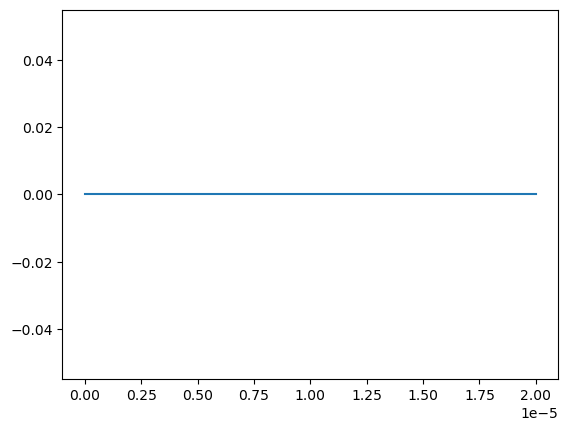

In [8]:
import matplotlib.pyplot as plt

c = np.array(c)

plt.plot(x, c.squeeze())
plt.show()

In [9]:
c_flat = c[0, 0, :]
